# Expanded universe (15-symbol) — 41d backtest

Current 8 live (deployed configs) + 7 near-miss ensemble candidates from the expansion test:

**Current (8):** BTC, HYPE, SOL, XRP, kPEPE, ENA, ZEC, xyz:CL — deployed params

**New near-miss (7):** PENDLE, TIA, OP, INJ, ETH, ARB, LINK — each on its best ensemble cell

(SUI dropped to fit the 15-symbol cap — it had the lowest OOS $+6 / P(win) 0.73.)

Same 15m HL data, same 0.03% commission, same 58bro sizing as the live bot.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import INSTRUMENTS
from config.deployer import load_all
import research.commod_backtest as cb
from research.ensemble_regime_test import bootstrap, q_pnls, split_stats
from research.current_vs_ensemble import (
    LIVE, SYM_LEV_EXP, _patch_weekday, _cfg_from_deployed,
    default_cfg, summarize,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Near-miss picks from the expansion test (ensemble_regime, 3×2×2 grid)
NEAR_MISS = {
    'PENDLE': {'K': 3, 'bos': True,  'exit': 'ensemble_hybrid'},
    'TIA':    {'K': 3, 'bos': True,  'exit': 'ensemble_hybrid'},
    'OP':     {'K': 5, 'bos': False, 'exit': 'ensemble_hybrid'},
    'INJ':    {'K': 5, 'bos': False, 'exit': 'ensemble_hybrid'},
    'ETH':    {'K': 4, 'bos': False, 'exit': 'ensemble_hybrid'},
    'ARB':    {'K': 3, 'bos': False, 'exit': 'ensemble_hybrid'},
    'LINK':   {'K': 4, 'bos': True,  'exit': 'ensemble_hybrid'},
}
print(f'universe = 8 live + {len(NEAR_MISS)} new = {8 + len(NEAR_MISS)}')

universe = 8 live + 7 new = 15


/Users/lucaneto/Trading/swing-trading-bot/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
dep_all = load_all()
results = {}; trade_log = {}

# --- 1) Current 8 live on deployed params ---
for sym in LIVE:
    d15 = cb.add_features(cb.fetch_hl(sym, '15m', 4000))
    d1h = cb.add_features(cb.fetch_hl(sym, '1h',  2000))
    d4h = cb.add_features(cb.fetch_hl(sym, '4h',  1000))
    arr = cb.precompute(d15, d1h, d4h)
    _patch_weekday(arr, sym)
    cfg = _cfg_from_deployed(dep_all[sym])
    lev = INSTRUMENTS[sym].hl_max_leverage * 0.15
    trades = cb.backtest(arr, cfg, lev)
    s = summarize(trades)
    s['bucket'] = 'current'; s['config'] = f"{cfg.entry_type}/{cfg.trend_filter_1h}"
    results[sym] = s; trade_log[sym] = trades

# --- 2) 7 near-miss on ensemble-best cells ---
for sym, spec in NEAR_MISS.items():
    d15 = cb.add_features(cb.fetch_hl(sym, '15m', 4000))
    d1h = cb.add_features(cb.fetch_hl(sym, '1h',  2000))
    d4h = cb.add_features(cb.fetch_hl(sym, '4h',  1000))
    arr = cb.precompute(d15, d1h, d4h)
    _patch_weekday(arr, sym)
    cfg = replace(default_cfg(),
                  entry_type='ensemble_regime', exit_type=spec['exit'],
                  ensemble_k=spec['K'], require_bos_confirm=spec['bos'],
                  tp1_atr=2.0, tp1_pct=0.3, tp2_atr=0.0, tp3_atr=0.0, trail_atr=0.0,
                  max_hold_bars=1000)
    lev = SYM_LEV_EXP.get(sym, 10) * 0.15
    trades = cb.backtest(arr, cfg, lev)
    s = summarize(trades)
    s['bucket'] = 'new'; s['config'] = f"ensemble K={spec['K']}/bos={'T' if spec['bos'] else 'F'}"
    results[sym] = s; trade_log[sym] = trades

rows = []
for sym, s in results.items():
    rows.append({'symbol': sym, 'bucket': s['bucket'], 'config': s['config'],
                 'n': s['n'], 'pf': round(s['pf'], 2) if s['pf'] else None,
                 'pnl': round(s['pnl'], 0), 'oos_pnl': round(s['oos_pnl'], 0),
                 'p_win': round(s['p_win'], 2), 'quartiles_pos': s['quarts_pos']})
df = pd.DataFrame(rows).sort_values(['bucket', 'pnl'], ascending=[True, False])

totals_cur = df[df['bucket']=='current'][['n','pnl','oos_pnl']].sum()
totals_new = df[df['bucket']=='new'][['n','pnl','oos_pnl']].sum()
totals_all = df[['n','pnl','oos_pnl']].sum()
print(f"Current 8 :  n={int(totals_cur['n'])}  $ {totals_cur['pnl']:+.0f}  OOS $ {totals_cur['oos_pnl']:+.0f}")
print(f"New 7     :  n={int(totals_new['n'])}  $ {totals_new['pnl']:+.0f}  OOS $ {totals_new['oos_pnl']:+.0f}")
print(f"TOTAL 15  :  n={int(totals_all['n'])}  $ {totals_all['pnl']:+.0f}  OOS $ {totals_all['oos_pnl']:+.0f}")
df

Current 8 :  n=269  $ +1607  OOS $ +969
New 7     :  n=194  $ +1794  OOS $ +946
TOTAL 15  :  n=463  $ +3401  OOS $ +1915


,symbol,bucket,config,n,pf,pnl,oos_pnl,p_win,quartiles_pos
3,XRP,current,bos_structural/hma_slope,36,2.80,730.0,356.0,0.97,3
0,BTC,current,regime_flip/hma_slope,49,1.20,349.0,162.0,0.65,4
1,HYPE,current,bos_structural/sjm,26,1.77,238.0,230.0,0.80,3
6,ZEC,current,swing_pivot/both_agree,44,1.55,231.0,61.0,0.77,3
5,ENA,current,swing_pivot/both_agree,29,2.16,122.0,61.0,0.96,3
2,SOL,current,bos_structural/sjm,30,1.21,101.0,126.0,0.63,3
7,xyz:CL,current,bb_touch/both_agree,30,2.13,66.0,43.0,0.94,3
4,kPEPE,current,bos_structural/sjm,25,0.57,-230.0,-70.0,0.13,0
8,PENDLE,new,ensemble K=3/bos=T,21,2.16,432.0,329.0,0.80,3
9,TIA,new,ensemble K=3/bos=T,22,2.41,388.0,334.0,0.75,3


## Per-symbol P&L — current (blue) vs new (green)

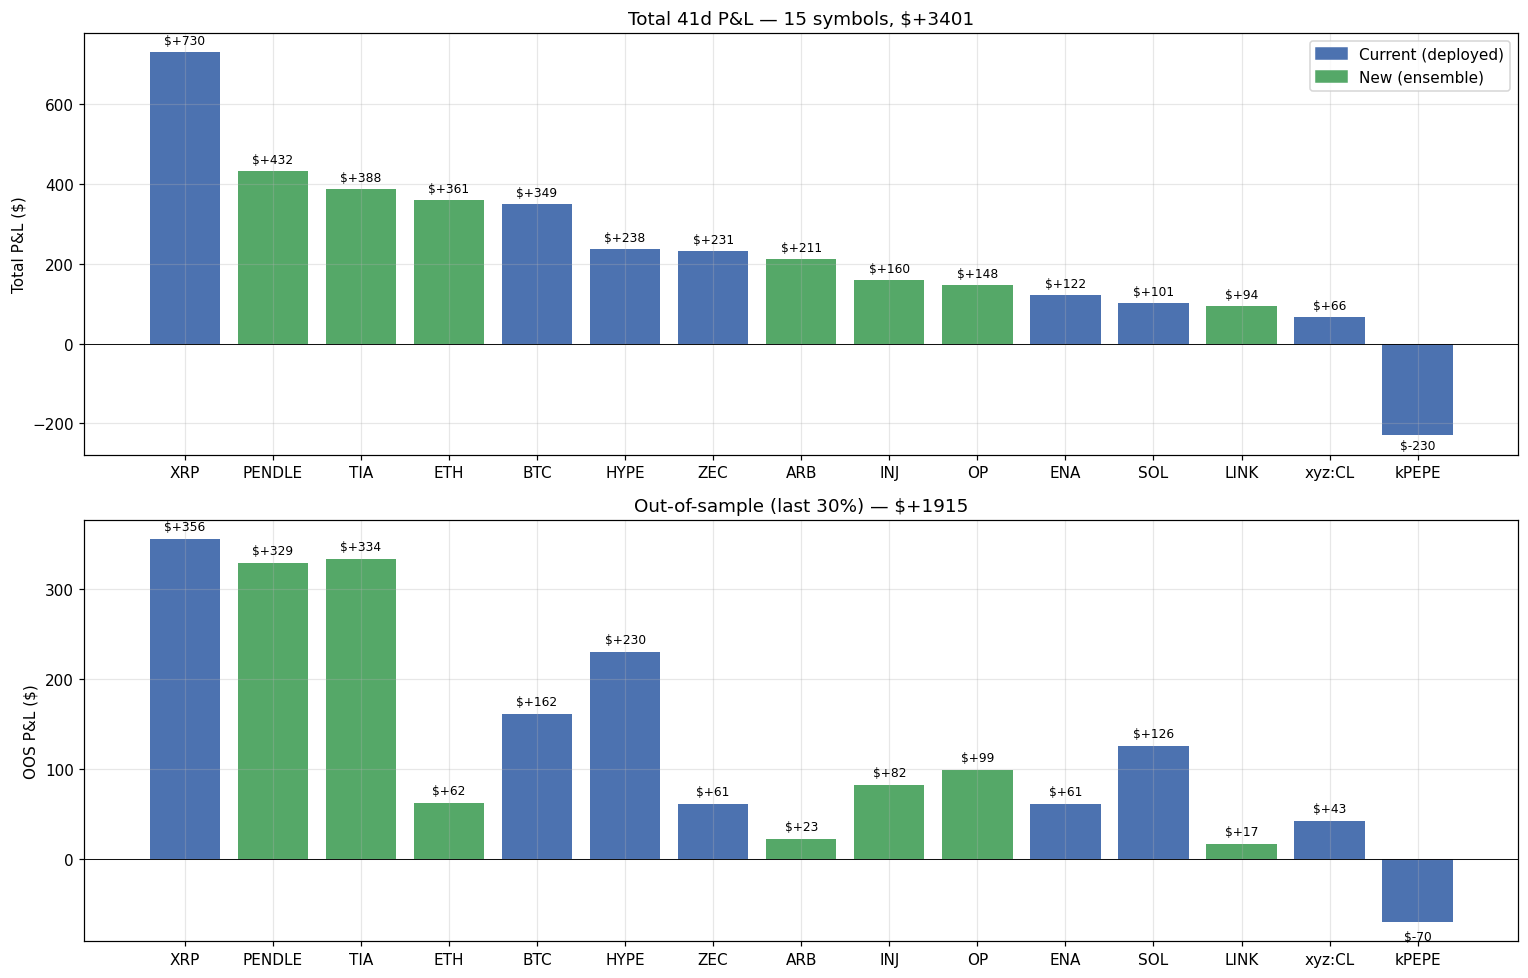

In [3]:
df2 = df.sort_values('pnl', ascending=False).reset_index(drop=True)
colors_total = ['#4C72B0' if b == 'current' else '#55A868' for b in df2['bucket']]
colors_oos = ['#4C72B0' if b == 'current' else '#55A868' for b in df2['bucket']]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].bar(df2['symbol'], df2['pnl'], color=colors_total)
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_ylabel('Total P&L ($)')
axes[0].set_title(f"Total 41d P&L — {len(df2)} symbols, ${df2['pnl'].sum():+.0f}")
for i, v in enumerate(df2['pnl']):
    axes[0].text(i, v + (20 if v >= 0 else -35), f"${v:+.0f}", ha='center', fontsize=8)

axes[1].bar(df2['symbol'], df2['oos_pnl'], color=colors_oos)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel('OOS P&L ($)')
axes[1].set_title(f"Out-of-sample (last 30%) — ${df2['oos_pnl'].sum():+.0f}")
for i, v in enumerate(df2['oos_pnl']):
    axes[1].text(i, v + (10 if v >= 0 else -20), f"${v:+.0f}", ha='center', fontsize=8)

# legend
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4C72B0', label='Current (deployed)'),
                          Patch(color='#55A868', label='New (ensemble)')])
plt.tight_layout(); plt.show()

## Portfolio equity curves

Three lines:
- Current 8 only (today's bot)
- New 7 only (if you only ran the additions)
- All 15 combined

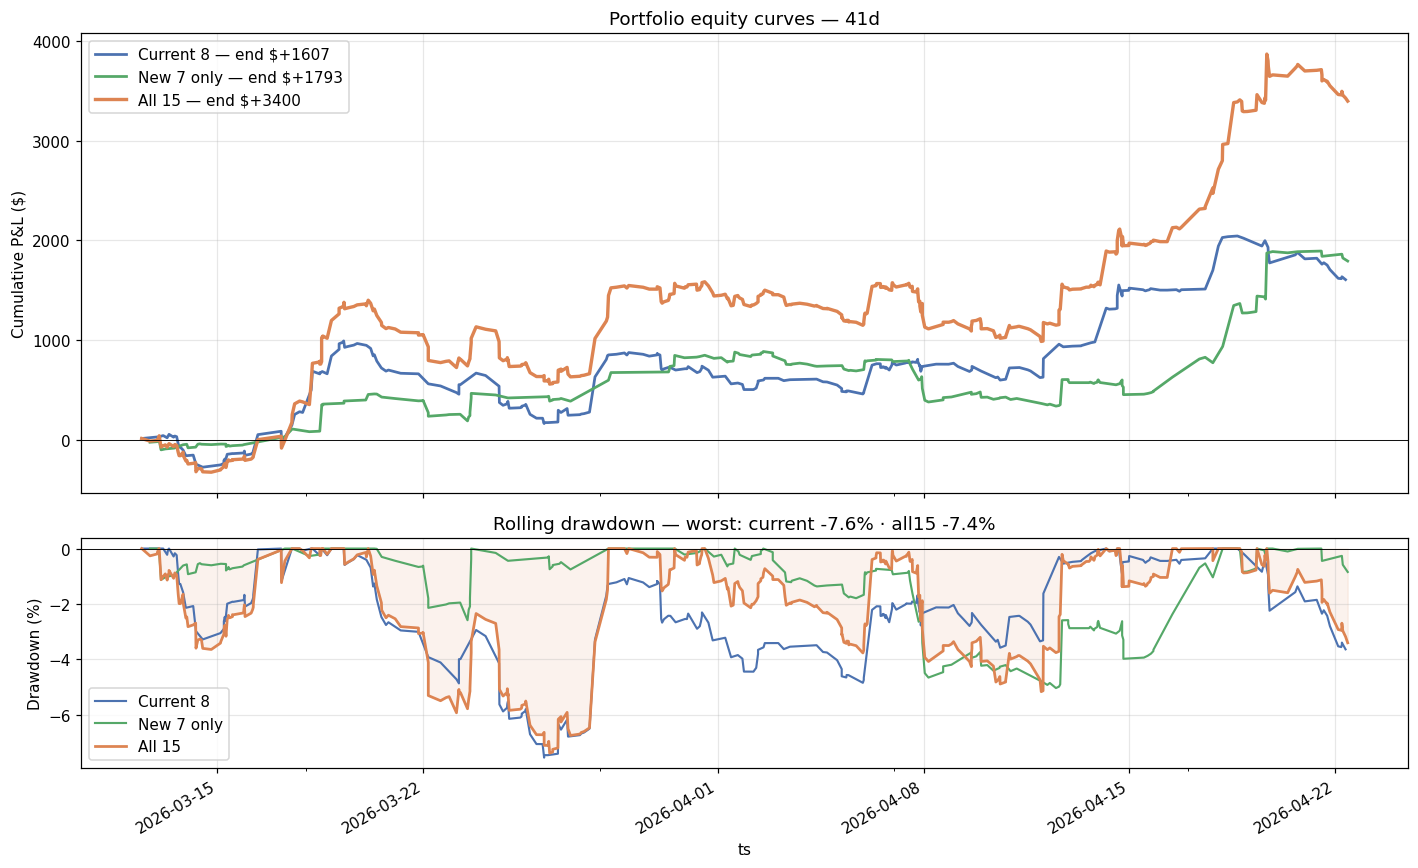

In [4]:
def eq(trade_log, syms):
    rows = []
    for sym in syms:
        for t in trade_log.get(sym, []):
            rows.append({'ts': pd.Timestamp(t['ts']), 'pnl': t['pnl']})
    if not rows: return pd.Series(dtype=float)
    d = pd.DataFrame(rows).sort_values('ts')
    d['cum'] = d['pnl'].cumsum()
    return d.set_index('ts')['cum']

cur_eq = eq(trade_log, LIVE)
new_eq = eq(trade_log, list(NEAR_MISS.keys()))
all_eq = eq(trade_log, LIVE + list(NEAR_MISS.keys()))

def drawdown(cum):
    equity = 10000 + cum
    peak = equity.cummax()
    return (equity - peak) / peak * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
cur_eq.plot(ax=axes[0], label=f'Current 8 — end ${cur_eq.iloc[-1]:+.0f}', color='#4C72B0', lw=1.8)
new_eq.plot(ax=axes[0], label=f'New 7 only — end ${new_eq.iloc[-1]:+.0f}', color='#55A868', lw=1.8)
all_eq.plot(ax=axes[0], label=f'All 15 — end ${all_eq.iloc[-1]:+.0f}', color='#DD8452', lw=2.2)
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].set_title('Portfolio equity curves — 41d')
axes[0].legend(loc='upper left')

drawdown(cur_eq).plot(ax=axes[1], label='Current 8', color='#4C72B0', lw=1.4)
drawdown(new_eq).plot(ax=axes[1], label='New 7 only', color='#55A868', lw=1.4)
drawdown(all_eq).plot(ax=axes[1], label='All 15', color='#DD8452', lw=1.8)
dd_all = drawdown(all_eq)
axes[1].fill_between(dd_all.index, dd_all.values, 0, alpha=0.1, color='#DD8452')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title(f"Rolling drawdown — worst: current {drawdown(cur_eq).min():.1f}% · all15 {dd_all.min():.1f}%")
axes[1].legend()
plt.tight_layout(); plt.show()

## Concurrency check — how often do signals overlap?

Your risk gate allows `max_concurrent=2` positions. If signals fire close in time on many symbols, slots fill and you miss trades. This chart shows concurrent open positions over time.

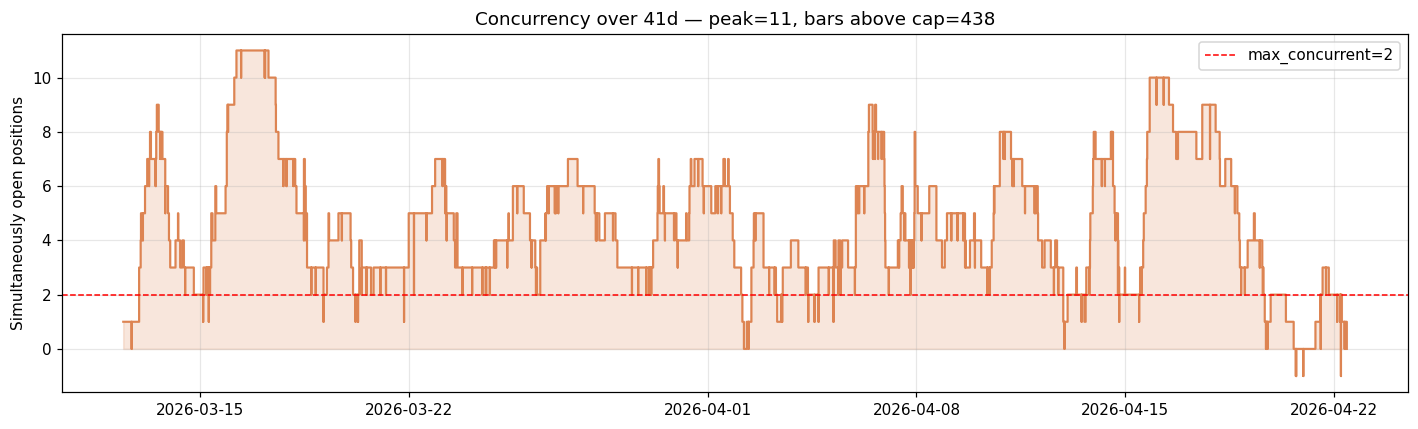

If max_concurrent=2: 438/582 events (~75%) would be BLOCKED
Peak concurrency needed for zero blocking: 11


In [5]:
# Rebuild per-position entry/exit timestamps
positions = []
for sym, trades in trade_log.items():
    groups = {}
    for t in trades:
        eb = t.get('entry_bar')
        if eb is None: continue
        groups.setdefault(eb, []).append(t)
    for eb, group in groups.items():
        exit_ts = max(t['ts'] for t in group)
        # entry_ts ≈ first bar of the position. Use the EARLIEST partial ts.
        entry_ts = min(t['ts'] for t in group)
        positions.append({'sym': sym, 'entry': pd.Timestamp(entry_ts), 'exit': pd.Timestamp(exit_ts)})
pos_df = pd.DataFrame(positions).sort_values('entry')

# Count concurrent positions — sweep line algorithm
events = []
for _, r in pos_df.iterrows():
    events.append((r['entry'], 1))
    events.append((r['exit'], -1))
events.sort()
ts_seq = []; open_count = 0; cnt_seq = []
for ts, delta in events:
    open_count += delta
    ts_seq.append(ts); cnt_seq.append(open_count)
conc = pd.Series(cnt_seq, index=pd.to_datetime(ts_seq))

fig, ax = plt.subplots(figsize=(13, 4))
ax.step(conc.index, conc.values, where='post', color='#DD8452', lw=1.4)
ax.fill_between(conc.index, conc.values, 0, step='post', alpha=0.2, color='#DD8452')
ax.axhline(2, color='red', linestyle='--', lw=1, label='max_concurrent=2')
ax.set_ylabel('Simultaneously open positions')
over_cap = int((conc > 2).sum())
peak = int(conc.max())
ax.set_title(f'Concurrency over 41d — peak={peak}, bars above cap={over_cap}')
ax.legend()
plt.tight_layout(); plt.show()
print(f'If max_concurrent=2: {over_cap}/{len(conc)} events (~{100*over_cap/max(len(conc),1):.0f}%) would be BLOCKED')
print(f'Peak concurrency needed for zero blocking: {peak}')